In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


# Iris Species Classification

### Objective
The objective is to classify a flower into one of the three Iris species (Veriscolor, Setosa, Virginica) using four input features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

In [4]:
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
143,144,6.8,3.2,5.9,2.3,Iris-virginica
113,114,5.7,2.5,5.0,2.0,Iris-virginica
128,129,6.4,2.8,5.6,2.1,Iris-virginica
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
3,4,4.6,3.1,1.5,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### Observations
- No missing/Null values
- Id column is not useful for analysis 

In [6]:
df = df.drop(columns="Id")

## Descriptive Statistics

In [7]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Duplicate Rows

In [8]:
df.duplicated().sum()

np.int64(3)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  147 non-null    float64
 1   SepalWidthCm   147 non-null    float64
 2   PetalLengthCm  147 non-null    float64
 3   PetalWidthCm   147 non-null    float64
 4   Species        147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB


## Target Variable Analysis

In [11]:
df["Species"].value_counts()

Species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

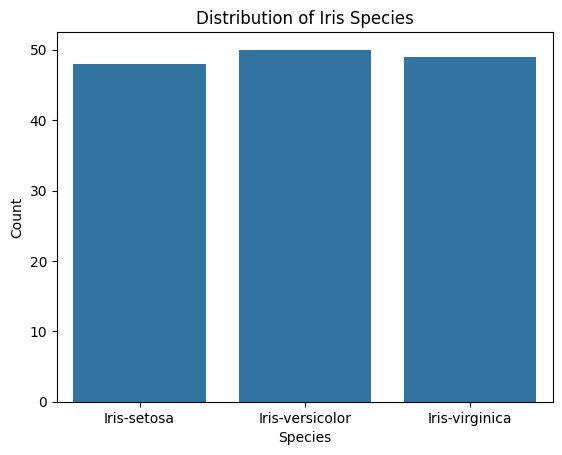

In [12]:
sns.countplot(data=df,x="Species")
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

### Observation
All categories are evenly distributed

In [13]:
cols = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]
titles = [
    "Sepal Length",
    "Sepal Width",
    "Petal Length",
    "Petal Width"
]

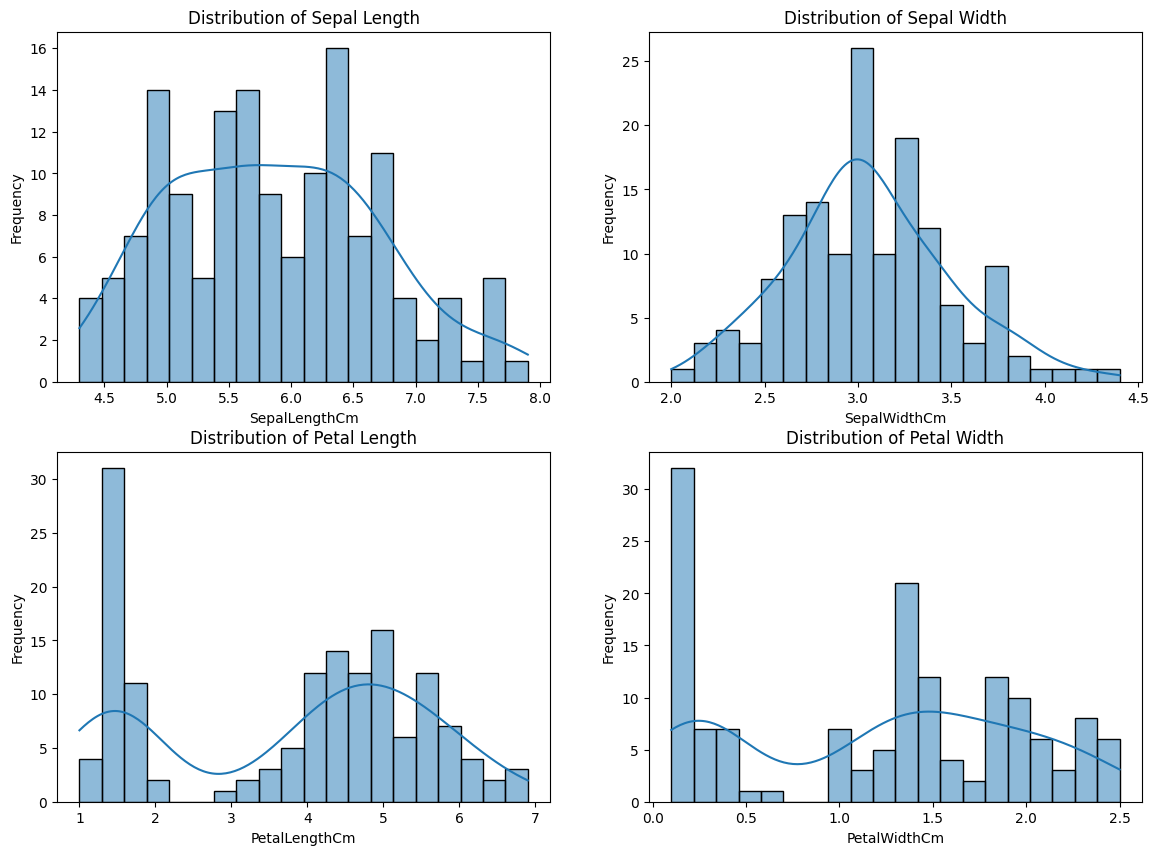

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    r = i // 2
    c = i % 2
    sns.histplot(data=df,x=col,bins=20,kde=True,ax=ax[r][c])
    ax[r][c].set_title(f"Distribution of {titles[i]}")
    ax[r][c].set_xlabel(col)
    ax[r][c].set_ylabel("Frequency")
    
plt.show()

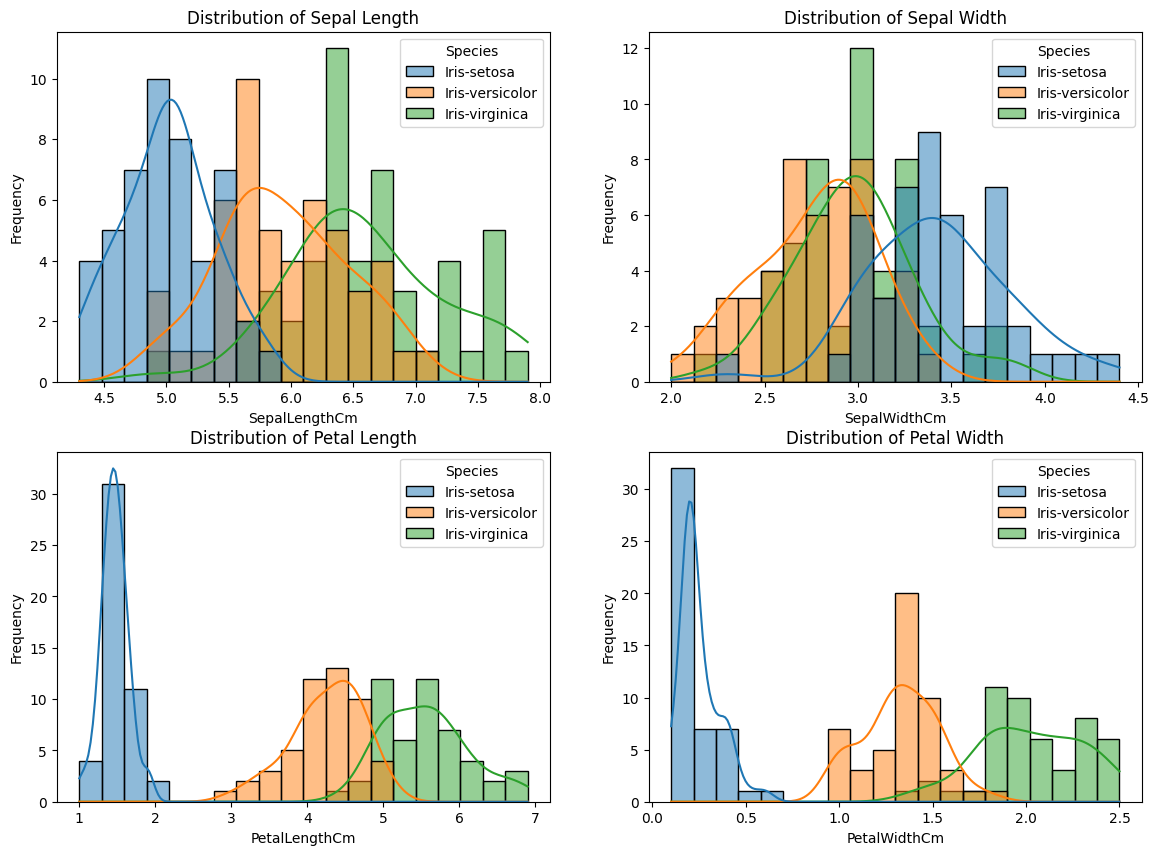

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    r = i // 2
    c = i % 2
    sns.histplot(data=df,x=col,bins=20,kde=True,ax=ax[r][c],hue="Species")
    ax[r][c].set_title(f"Distribution of {titles[i]}")
    ax[r][c].set_xlabel(col)
    ax[r][c].set_ylabel("Frequency")
    
plt.show()

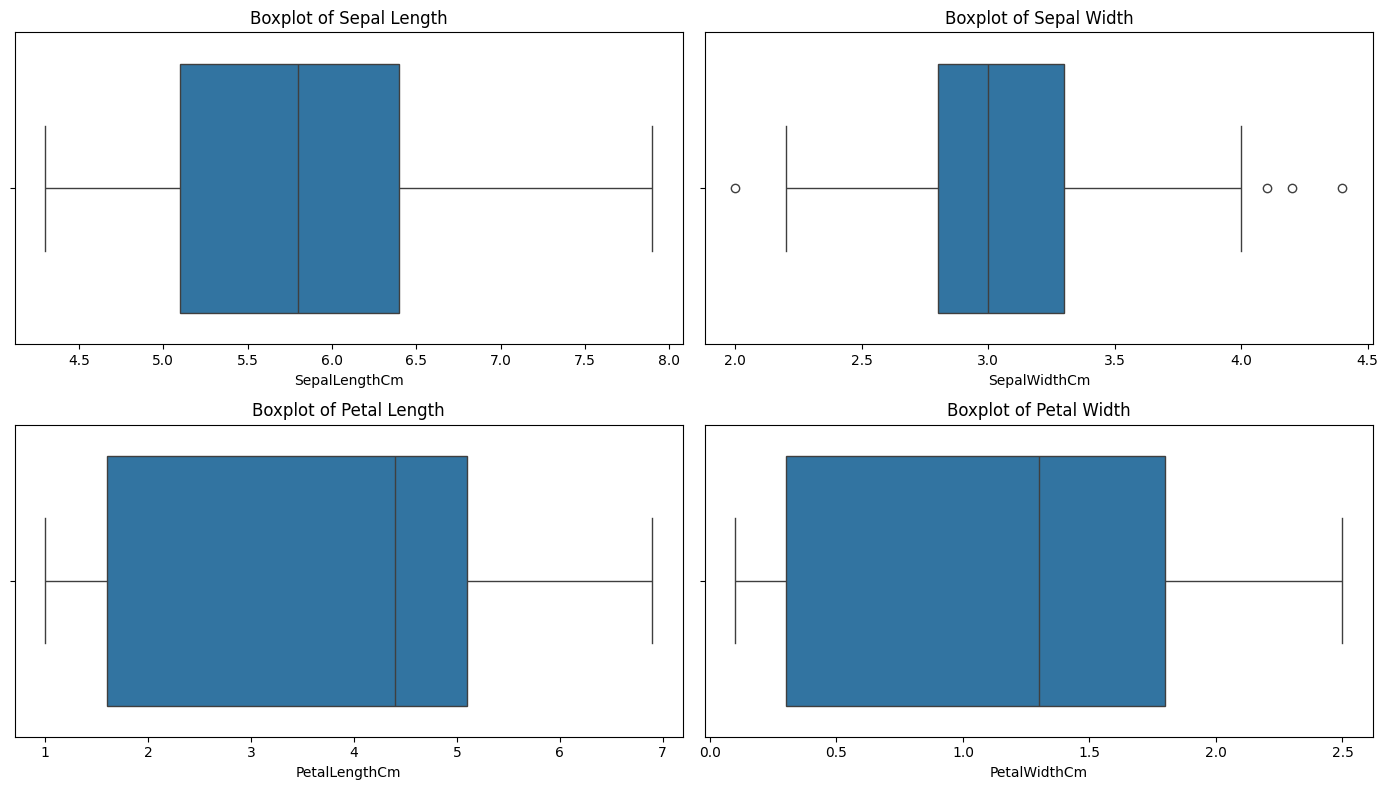

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(cols):
    r = i // 2
    c = i % 2

    sns.boxplot(x=df[col],ax=ax[r][c])
    ax[r][c].set_title(f"Boxplot of {titles[i]}")
    ax[r][c].set_xlabel(col)

plt.tight_layout()
plt.show()

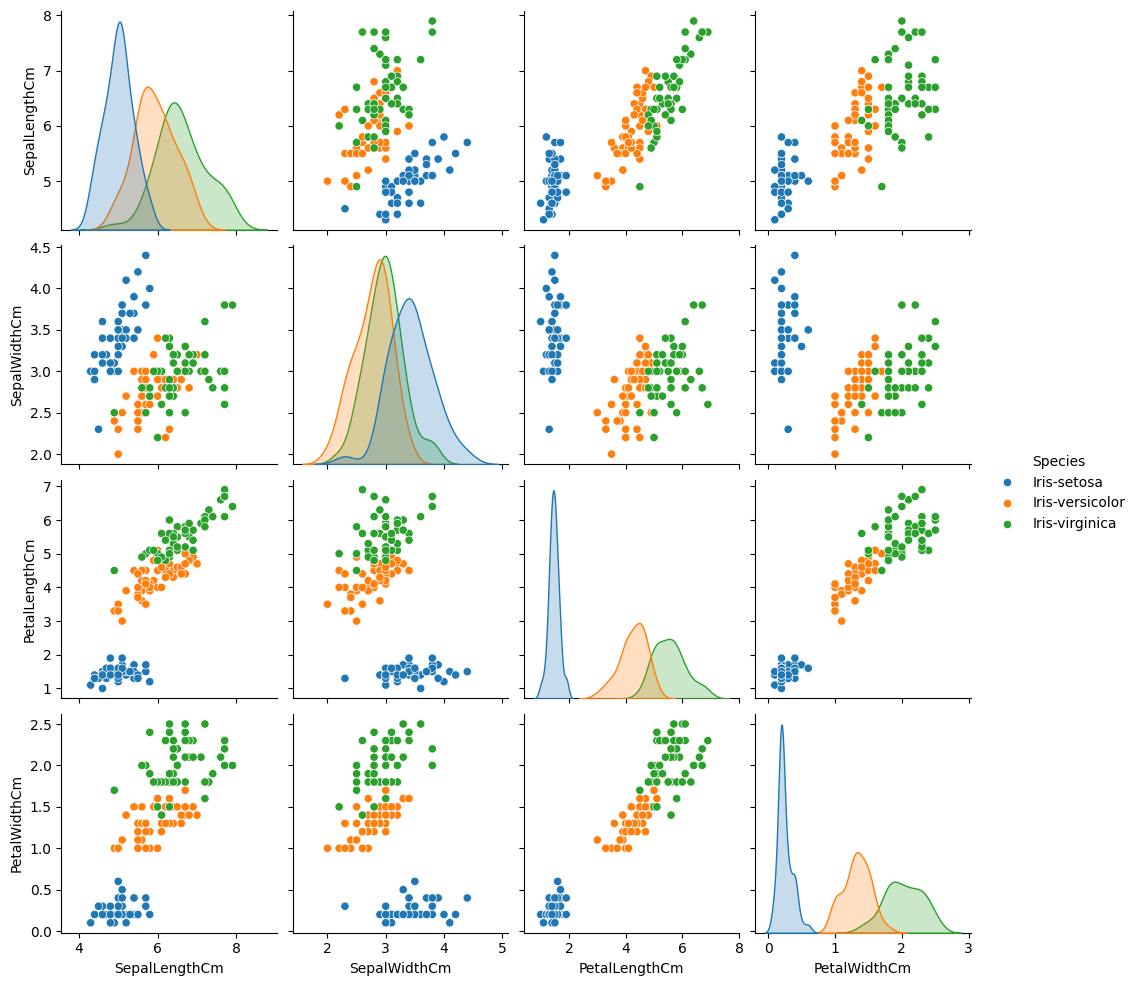

In [17]:
sns.pairplot(df,hue="Species")
plt.show()

## EDA Observations

### Sepal Length
- Normal Distribution
- Value ranges overlap over three species
- IQR Range between 5cm and 6.5cm

### Sepal Width
- Normal Distribution
- Have some outliers
- Value ranges overlap over three species
- IQR Range between 2.5cm and 3.5cm

### Petal Length
- Bimodal Distribution
- Excellent Feature for distinguishing Sentosa from other two species
- Sentosa Range (1 to 2 cm)
- Other Range (3 to 7 cm)

### Petal Width
- Same distribution as Petal Length
- Sentosa Range (less than 0.5 cm)
- Other Range (1 to 2.5 cm)

So, Petal length and Petal width are promising features for distinguishing Sentosa from other 2 species

- Petal Length and Petal Width show a positive correlation
- Petal Length vs Petal Width graph in pair plot clearly distinguishes sentosa from other 2 and Virginica and Versicolor have slight overlap


## Heatmap

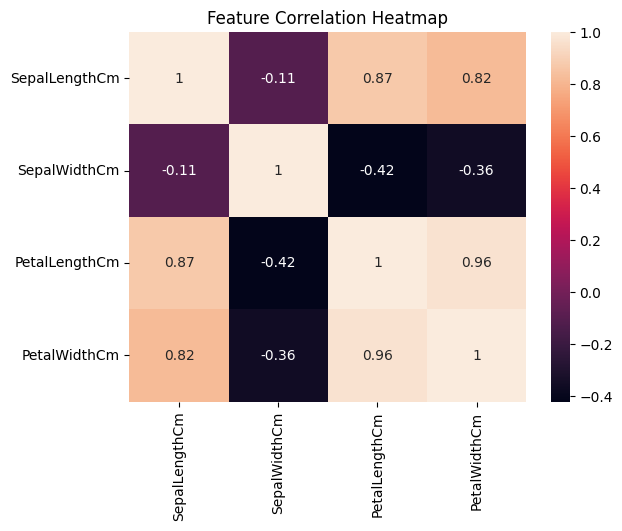

In [18]:
corr = df.drop("Species", axis=1).corr()
sns.heatmap(corr,annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

### Positive Correlations
- Sepal Length vs Petal Length
- Sepal Length vs Petal Width
- Petal Length vs Petal Width

## Data Preprocessing

In [19]:
X = df.drop("Species",axis=1)
y = df["Species"]

In [20]:
X.shape

(147, 4)

In [21]:
y.shape

(147,)

In [22]:
# Label Encoding Species
mapping = {
    "Iris-setosa":0,
    "Iris-versicolor":1,
    "Iris-virginica":2
}

df["Species"] = df["Species"].map(mapping)

In [23]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
134,6.1,2.6,5.6,1.4,2
128,6.4,2.8,5.6,2.1,2
36,5.5,3.5,1.3,0.2,0
102,7.1,3.0,5.9,2.1,2
73,6.1,2.8,4.7,1.2,1


In [24]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(117, 4)
(30, 4)
(117,)
(30,)


In [26]:
y_train.value_counts()

Species
Iris-virginica     40
Iris-versicolor    40
Iris-setosa        37
Name: count, dtype: int64

In [27]:
y_test.value_counts()

Species
Iris-setosa        11
Iris-versicolor    10
Iris-virginica      9
Name: count, dtype: int64

In [28]:
## Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Text(0.5, 1.0, 'After Scaling')

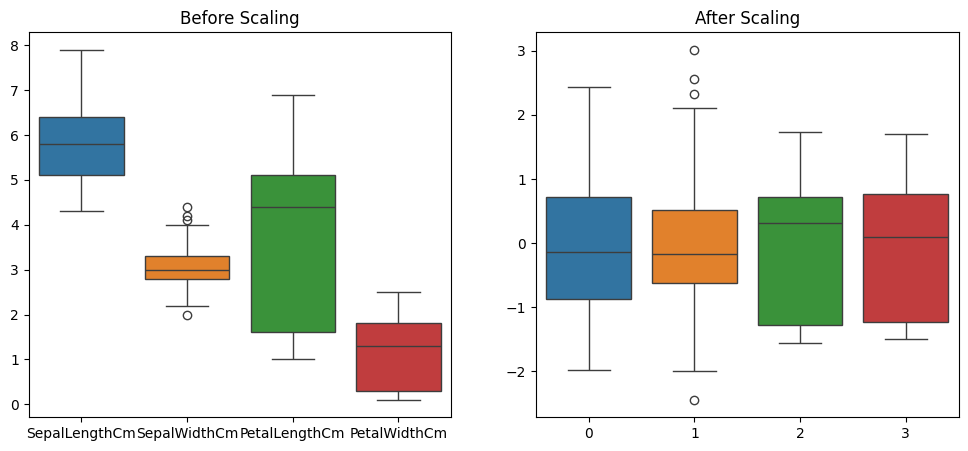

In [29]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
sns.boxplot(data=pd.DataFrame(X), ax=ax[0])
ax[0].set_title("Before Scaling")
sns.boxplot(data=pd.DataFrame(X_train), ax=ax[1])
ax[1].set_title("After Scaling")

## Model

In [30]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [31]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [32]:
print("Training Accuracy")
print(model.score(X_train, y_train))

Training Accuracy
0.9743589743589743


In [33]:
print("Testing Accuracy")
print(model.score(X_test, y_test))

Testing Accuracy
0.9333333333333333


In [34]:
from sklearn.metrics import confusion_matrix
c_matrix = confusion_matrix(y_test, y_pred)
print(c_matrix)

[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]


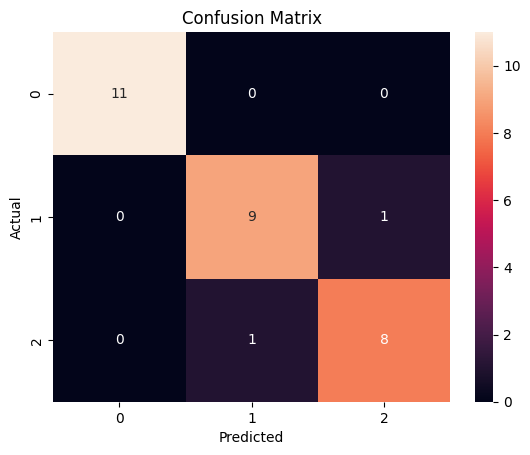

In [35]:
sns.heatmap(c_matrix,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Using Only Petal Length and Petal Width

In [36]:
X = df[["PetalLengthCm", "PetalWidthCm"]]
y = df["Species"]

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [38]:
print("Training Accuracy")
print(model.score(X_train, y_train))
print("Testing Accuracy")
print(model.score(X_test, y_test))

Training Accuracy
0.9572649572649573
Testing Accuracy
0.9333333333333333


In [39]:
c_matrix = confusion_matrix(y_test, y_pred)
print(c_matrix)

[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]


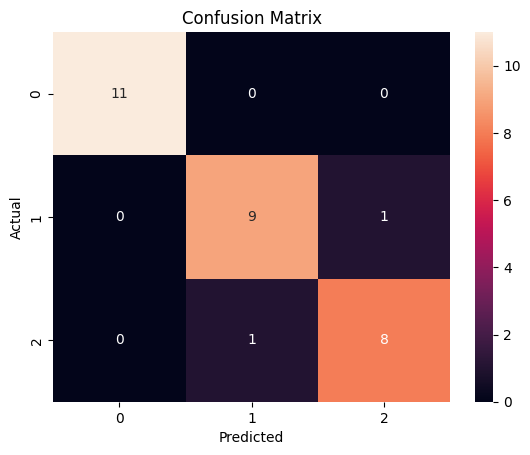

In [40]:
sns.heatmap(c_matrix,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()